# Figure 3f — LOI motif-feature-space UMAP

In [ ]:
import os
from pathlib import Path

# Shared Conda/user configuration paths can be read-only. Set caches before
# importing Matplotlib or umap-learn so interactive execution is warning-free.
CACHE_ROOT = Path('/tmp/yyj_figure3f_cache')
NUMBA_CACHE_DIR = CACHE_ROOT / 'numba'
MPLCONFIGDIR = CACHE_ROOT / 'matplotlib'
NUMBA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('NUMBA_CACHE_DIR', str(NUMBA_CACHE_DIR))
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError(
        'This notebook requires umap-learn. Install it in the active environment, '
        'for example: conda install -c conda-forge umap-learn'
    ) from exc


def find_project_root() -> Path:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / 'LCMWR' / 'results').is_dir() and (candidate / 'paper_figures').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from the YYJ project or set PROJECT_ROOT manually.')


PROJECT_ROOT = find_project_root()
TASK = 'loi'
RANDOM_STATE = 48
N_NEIGHBORS = 5
MIN_DIST = 0.8
METRIC = 'euclidean'
INIT = 'random'
ROUND_DECIMALS = 5

MATRIX_PATH = PROJECT_ROOT / 'LCMWR' / 'results' / f'{TASK}_motif_select' / f'{TASK}_vocab_weighted_feature_matrix.csv'
SELECTED_PATH = PROJECT_ROOT / 'LCMWR' / 'results' / f'{TASK}_motif_select' / 'best_improved_final_features_info.csv'
OUTPUT_PATH = PROJECT_ROOT / 'paper_figures' / 'data' / 'figure3_drawing_data' / f'figure3f_{TASK}_motif_umap_coordinates.csv'
SELECTED_OUTPUT_PATH = PROJECT_ROOT / 'paper_figures' / 'data' / 'figure3_drawing_data' / f'figure3f_{TASK}_selected_motif_umap_coordinates.csv'

print(f'Input matrix: {MATRIX_PATH}')
print(f'All-motif coordinate output: {OUTPUT_PATH}')
print(f'Selected-motif coordinate output: {SELECTED_OUTPUT_PATH}')

In [44]:
# The matrix has one row per LOI sample and one column per active motif.
# Transposition makes every UMAP observation a motif.
sample_by_motif = pd.read_csv(MATRIX_PATH).round(ROUND_DECIMALS)
motif_by_sample = sample_by_motif.T
motif_by_sample.index.name = 'smiles'

# A constant profile contains no geometric information. This is normally zero
# for the current active feature matrix, but is retained as an explicit audit.
nonconstant = motif_by_sample.var(axis=1) > 1e-12
motif_by_sample = motif_by_sample.loc[nonconstant].copy()

selected = pd.read_csv(SELECTED_PATH)
selected_smiles = set(selected['feature_name'])

print(f'Loaded sample × motif matrix: {sample_by_motif.shape}; values rounded to {ROUND_DECIMALS} decimals')
print(f'Motifs included in UMAP: {motif_by_sample.shape[0]}')
print(f'LOI final selected motifs: {motif_by_sample.index.isin(selected_smiles).sum()}')

Loaded sample × motif matrix: (948, 5535); values rounded to 5 decimals
Motifs included in UMAP: 5535
LOI final selected motifs: 187


In [ ]:
# Standardise each sample dimension before distance calculation so no single
# high-magnitude sample dominates the motif-to-motif Euclidean distance.
X = StandardScaler().fit_transform(motif_by_sample.to_numpy(dtype=np.float32))

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    metric=METRIC,
    init=INIT,
    random_state=RANDOM_STATE,
)
embedding = reducer.fit_transform(X)

coordinates = pd.DataFrame(
    {
        'smiles': motif_by_sample.index,
        'umap_1': embedding[:, 0],
        'umap_2': embedding[:, 1],
        'selected_loi': motif_by_sample.index.isin(selected_smiles),
        'n_samples': motif_by_sample.shape[1],
        'random_state': RANDOM_STATE,
        'n_neighbors': N_NEIGHBORS,
        'min_dist': MIN_DIST,
        'metric': METRIC,
        'initialization': INIT,
        'scaling': 'StandardScaler_per_sample_dimension',
        'input_round_decimals': ROUND_DECIMALS,
    }
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
coordinates.to_csv(OUTPUT_PATH, index=False)
selected_coordinates = coordinates.loc[coordinates['selected_loi']].copy()
selected_coordinates.to_csv(SELECTED_OUTPUT_PATH, index=False)
print(f'Wrote {len(coordinates)} all-motif coordinates to {OUTPUT_PATH}')
print(f'Wrote {len(selected_coordinates)} LOI selected-motif coordinates to {SELECTED_OUTPUT_PATH}')
coordinates.head()

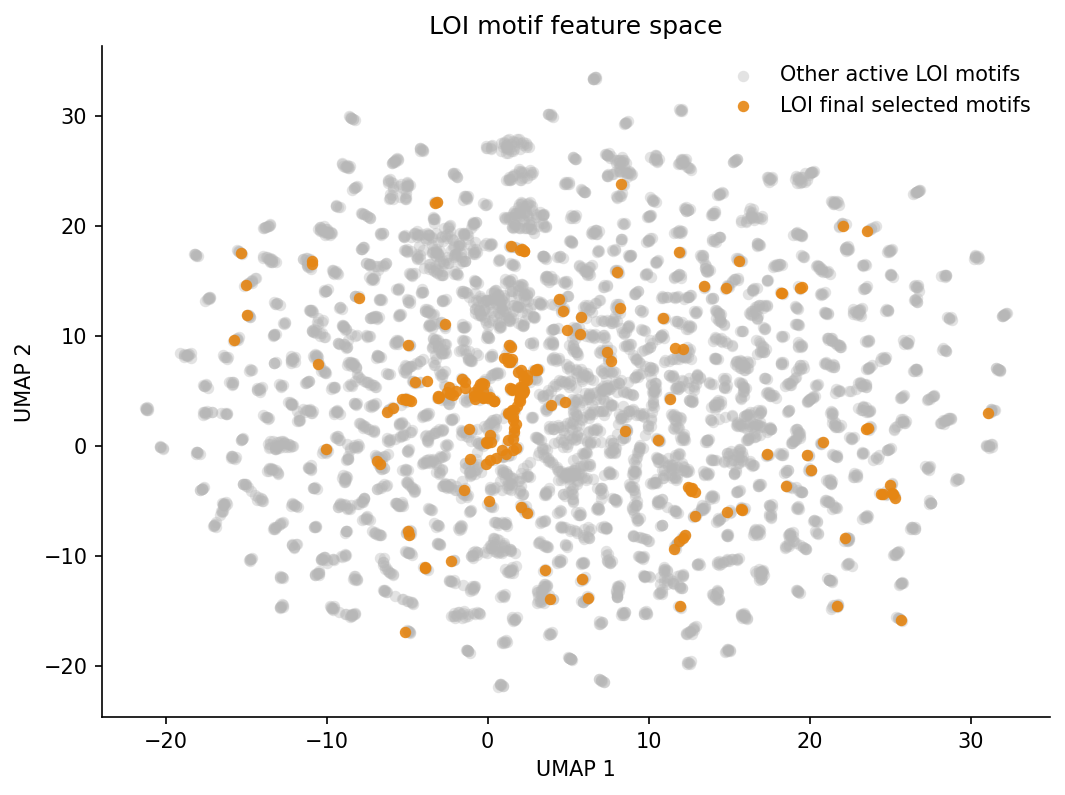

In [46]:
# Preview only. Final panel typography/layout belongs to paper_figures/Origin.
fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=150)
other = coordinates.loc[~coordinates['selected_loi']]
kept = coordinates.loc[coordinates['selected_loi']]
ax.scatter(other['umap_1'], other['umap_2'], s=30, c='#B7B7B7', alpha=0.38, linewidths=0, label='Other active LOI motifs')
ax.scatter(kept['umap_1'], kept['umap_2'], s=30, c='#E68613', alpha=0.90, linewidths=0, label='LOI final selected motifs')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('LOI motif feature space')
ax.legend(frameon=False, loc='best')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## Handoff to Origin

Import `figure3f_loi_motif_umap_coordinates.csv` from `paper_figures/data/figure3_drawing_data/`. Plot `umap_1` (X) versus `umap_2` (Y), grouping by `selected_loi`. Retain the parameters stored in the CSV as graph notes/provenance. The inline plot is a verification preview, not the final manuscript panel.